divide the sequence with k = 8, find all the difference k-mers, exist in the sequence and divide by the number of all posible k-mers

read the whole chromosome 1 hg38, for k=500 (slide window, every 20?) run kolmogorov with k=8 

kolmogorov
divine the given sequence (k=500), in all existence k-mers (k<=8) using slide window, 
normalize
I have 64 possible 3-mers, lets say I find 48 different 3-mers in my seq, 48/64 (4^k)



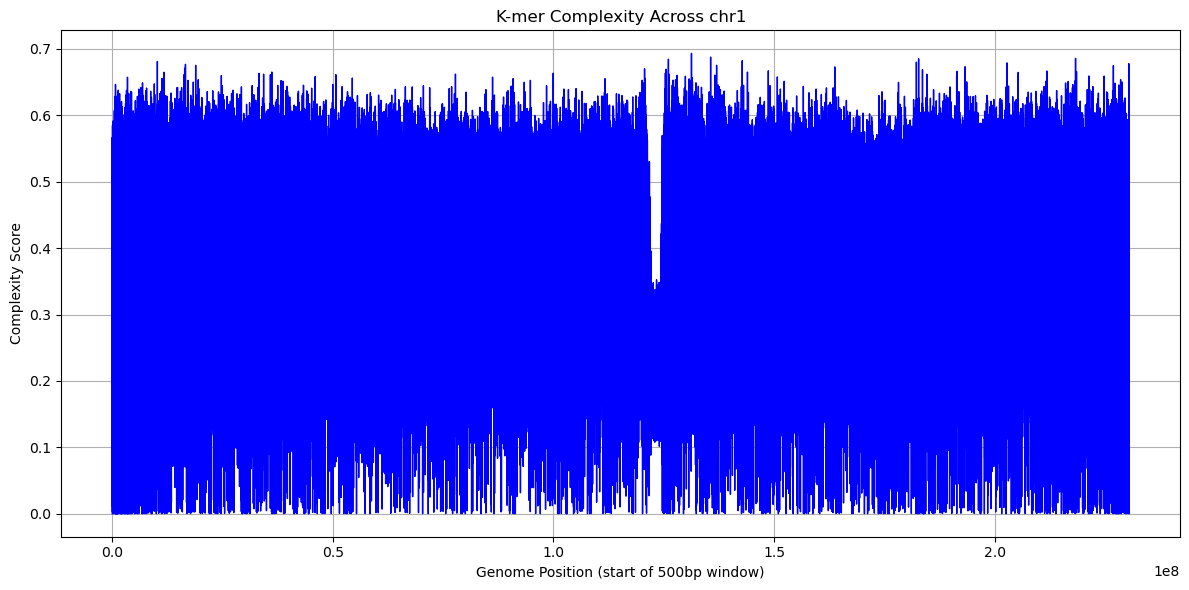

In [7]:
import matplotlib.pyplot as plt
import math
def find_kmers(sequence):
    sequence = sequence.upper()
    kmers_dict = {}
    l = len(sequence)
    for k in range(1, 8):
        max_kmers = l - k + 1
        kmers = set()
        for i in range(max_kmers):
            kmer = sequence[i:i + k]
            kmers.add(kmer)
        if 4**k <= max_kmers:
            kmers_dict[k] = len(kmers) / (4**k)
        else:
            kmers_dict[k] = len(kmers) / max_kmers
    return kmers_dict

with open("chr1.fa", 'r') as file:
    raw = file.read().upper()
    dna_seq = ''.join(base for base in raw if base in {'A', 'T', 'C', 'G'})

window_size = 500
step = 100
complexity_scores = []
positions =[]
for j in range(0, len(dna_seq) - window_size + 1, step):
    window= dna_seq[j:j+window_size]
    kmers = find_kmers(window)
    complexity_values = list(kmers.values())
    complexity_score = math.prod(complexity_values)
    positions.append(j)
    complexity_scores.append(complexity_score)

plt.figure(figsize=(12, 6))
plt.plot(positions, complexity_scores, color='blue', linewidth=1)
plt.title("K-mer Complexity Across chr1")
plt.xlabel("Genome Position (start of 500bp window)")
plt.ylabel("Complexity Score")
plt.grid(True)
plt.tight_layout()
plt.show()
